# Flow-Based Intrusion Detection System (IDS) - NSL-KDD Baseline

**ECE 57000 Project - Track 2: ProductPrototype**


## 1. Install & Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay)
from sklearn.utils import resample
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## 2. Load NSL-KDD Dataset

In [ ]:
# NSL-KDD column names (the dataset ships without headers)
# 41 features + label + difficulty_level
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty_level"]

# Download directly
TRAIN_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
TEST_URL  = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt"

df_train = pd.read_csv(TRAIN_URL, header=None, names=col_names)
df_test  = pd.read_csv(TEST_URL,  header=None, names=col_names)

print(f"Training samples: {len(df_train)}")
print(f"Test samples:     {len(df_test)}")
display(df_train.head())

Training samples: 125973
Test samples:     22544


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 3. Preprocessing

In [ ]:
# Map 39 fine-grained labels to 5-class categories
# Normal, DoS, Probe, R2L (Remote-to-Local), U2R (User-to-Root)

attack_map = {
    'normal': 'Normal',
    # DoS
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS',
    'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    # Probe
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'satan': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    # R2L
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L',
    'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L',
    'warezclient': 'R2L', 'warezmaster': 'R2L', 'snmpgetattack': 'R2L',
    'named': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L',
    'sendmail': 'R2L', 'httptunnel': 'R2L', 'worm': 'R2L',
    'snmpguess': 'R2L',
    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'rootkit': 'U2R', 'xterm': 'U2R', 'ps': 'U2R',
    'sqlattack': 'U2R',}

df_train['attack_cat'] = df_train['label'].map(attack_map).fillna('Unknown')
df_test['attack_cat']  = df_test['label'].map(attack_map).fillna('Unknown')

# Also create binary label (Normal vs Attack)
df_train['is_attack'] = (df_train['attack_cat'] != 'Normal').astype(int)
df_test['is_attack']  = (df_test['attack_cat'] != 'Normal').astype(int)

print("Training class distribution (5-class):")
print(df_train['attack_cat'].value_counts())

Training class distribution (5-class):
attack_cat
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [ ]:
# Encode categorical features & scale
cat_cols = ['protocol_type', 'service', 'flag']
drop_cols = ['label', 'difficulty_level', 'attack_cat', 'is_attack']
X_train = df_train.drop(columns=drop_cols)
X_test  = df_test.drop(columns=drop_cols)
num_cols = [c for c in X_train.columns if c not in cat_cols]
# ColumnTransformer: OHE for categoricals, StandardScaler for numerics
preprocessor = ColumnTransformer([('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),])
# Fit on train only, transform both
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled  = preprocessor.transform(X_test)
# Targets 5-class
y_train_cat = df_train['attack_cat']
y_test_cat  = df_test['attack_cat']
le_target = LabelEncoder()
y_train = le_target.fit_transform(y_train_cat)
y_test  = le_target.transform(y_test_cat)

print(f"Feature matrix shape: {X_train_scaled.shape}")
print(f"Classes: {le_target.classes_}")

Feature matrix shape: (125973, 122)
Classes: ['DoS' 'Normal' 'Probe' 'R2L' 'U2R']


## 4. Train Random Forest Baseline

In [ ]:
# Baseline Random Forest with default class distribution (no balancing)

rf = RandomForestClassifier(n_estimators=100, max_depth=20,
    random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')
print(f"Test Accuracy:    {acc:.4f}")
print(f"Test F1 (weighted): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Test Accuracy:    0.7553
Test F1 (weighted): 0.7089

Classification Report:
              precision    recall  f1-score   support

         DoS       0.96      0.81      0.88      7458
      Normal       0.66      0.97      0.78      9711
       Probe       0.82      0.60      0.69      2421
         R2L       0.94      0.02      0.04      2887
         U2R       0.67      0.03      0.06        67

    accuracy                           0.76     22544
   macro avg       0.81      0.49      0.49     22544
weighted avg       0.81      0.76      0.71     22544



## 5. Confusion Matrix & Visualizations

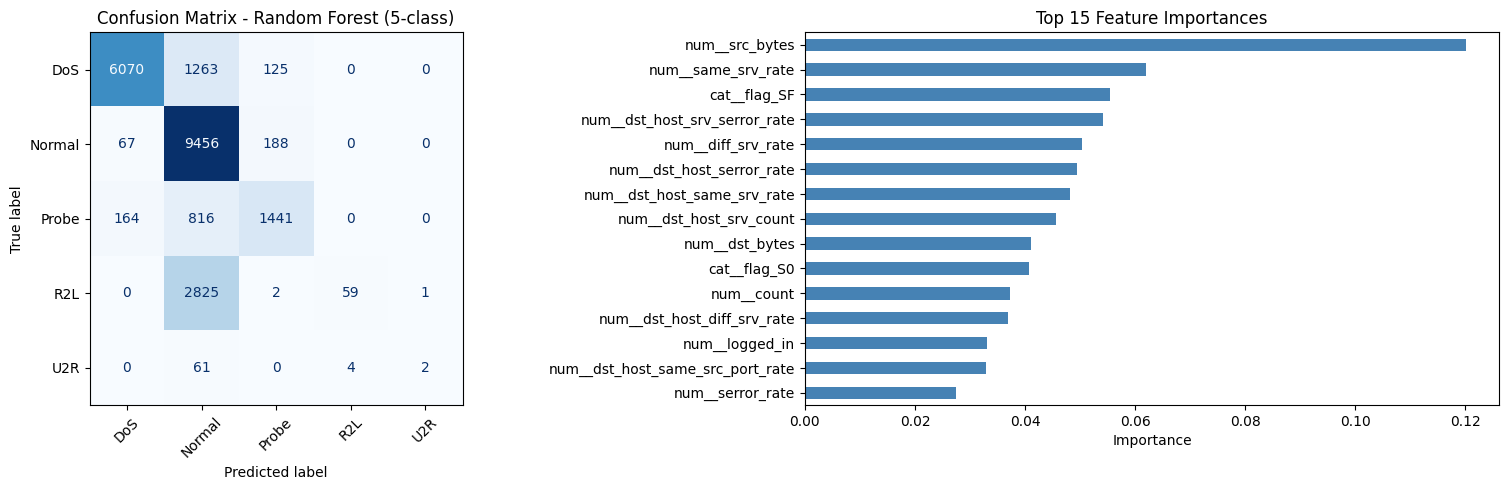

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - Random Forest (5-class)')
axes[0].tick_params(axis='x', rotation=45)

# Feature Importance (Top 15)
feat_names = preprocessor.get_feature_names_out()
feat_imp = pd.Series(rf.feature_importances_, index=feat_names)
top15 = feat_imp.nlargest(15)
top15.sort_values().plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('results_figure.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Quick Binary Classification (Normal vs Attack)

In [ ]:
y_train_bin = df_train['is_attack'].values
y_test_bin  = df_test['is_attack'].values

rf_bin = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_bin.fit(X_train_scaled, y_train_bin)
y_pred_bin = rf_bin.predict(X_test_scaled)

print("Binary Classification (Normal vs Attack)")
print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_bin):.4f}")
print(f"F1:       {f1_score(y_test_bin, y_pred_bin):.4f}")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal','Attack']))

Binary Classification (Normal vs Attack)
Accuracy: 0.7697
F1:       0.7529
              precision    recall  f1-score   support

      Normal       0.66      0.97      0.78      9711
      Attack       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.77     22544



## 7. XGBoost with Class Weighting

In [ ]:
# Compute class weights from training distribution
class_counts = Counter(y_train)
total = sum(class_counts.values())
n_classes = len(class_counts)

# Compute inverse-frequency class weights to penalize misclassifying rare classes
# weight_i = total / (n_classes * count_i)
sample_weights_train = np.array([
    total / (n_classes * class_counts[label]) for label in y_train])

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1)

xgb.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)

y_pred_xgb = xgb.predict(X_test_scaled)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
print(f"XGBoost Test Accuracy:      {acc_xgb:.4f}")
print(f"XGBoost Test F1 (weighted): {f1_xgb:.4f}")
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le_target.classes_))

XGBoost Test Accuracy:      0.7858
XGBoost Test F1 (weighted): 0.7484

XGBoost Classification Report:
              precision    recall  f1-score   support

         DoS       0.97      0.84      0.90      7458
      Normal       0.69      0.97      0.81      9711
       Probe       0.81      0.72      0.76      2421
         R2L       0.98      0.08      0.15      2887
         U2R       0.71      0.25      0.37        67

    accuracy                           0.79     22544
   macro avg       0.83      0.57      0.60     22544
weighted avg       0.83      0.79      0.75     22544



## 8. Random Forest with class_weight='balanced'


In [ ]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

rf_balanced.fit(X_train_scaled, y_train)

y_pred_rf_bal = rf_balanced.predict(X_test_scaled)

acc_rf_bal = accuracy_score(y_test, y_pred_rf_bal)
f1_rf_bal = f1_score(y_test, y_pred_rf_bal, average='weighted')
print(f"RF-Balanced Test Accuracy:      {acc_rf_bal:.4f}")
print(f"RF-Balanced Test F1 (weighted): {f1_rf_bal:.4f}")
print("\nRF-Balanced Classification Report:")
print(classification_report(y_test, y_pred_rf_bal, target_names=le_target.classes_))

RF-Balanced Test Accuracy:      0.7533
RF-Balanced Test F1 (weighted): 0.7054

RF-Balanced Classification Report:
              precision    recall  f1-score   support

         DoS       0.96      0.81      0.88      7458
      Normal       0.65      0.97      0.78      9711
       Probe       0.86      0.60      0.70      2421
         R2L       0.93      0.01      0.02      2887
         U2R       0.50      0.03      0.06        67

    accuracy                           0.75     22544
   macro avg       0.78      0.48      0.49     22544
weighted avg       0.81      0.75      0.71     22544



## 9. Simple MLP (Neural Network)

In [ ]:
# Two-layer neural network (128, 64) with early stopping on validation loss

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=100,
    batch_size=256,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42)

mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp, average='weighted')
print(f"MLP Test Accuracy:      {acc_mlp:.4f}")
print(f"MLP Test F1 (weighted): {f1_mlp:.4f}")
print("\nMLP Classification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=le_target.classes_))

MLP Test Accuracy:      0.7742
MLP Test F1 (weighted): 0.7323

MLP Classification Report:
              precision    recall  f1-score   support

         DoS       0.97      0.83      0.89      7458
      Normal       0.68      0.97      0.80      9711
       Probe       0.76      0.68      0.72      2421
         R2L       0.94      0.05      0.09      2887
         U2R       0.85      0.25      0.39        67

    accuracy                           0.77     22544
   macro avg       0.84      0.56      0.58     22544
weighted avg       0.82      0.77      0.73     22544



## 10. Comparison Table & Visualization

,Model,Accuracy,Weighted F1,DoS F1,DoS Recall,Normal F1,Normal Recall,Probe F1,Probe Recall,R2L F1,R2L Recall,U2R F1,U2R Recall
0,RF (CP1),0.7553,0.7089,0.8823,0.8139,0.7837,0.9737,0.6900,0.5952,0.0400,0.0204,0.0571,0.0299
1,RF-Balanced,0.7533,0.7054,0.8811,0.8119,0.7800,0.9738,0.7022,0.5956,0.0185,0.0094,0.0563,0.0299
2,XGBoost,0.7858,0.7484,0.8991,0.8410,0.8091,0.9724,0.7635,0.7216,0.1508,0.0817,0.3736,0.2537
3,MLP,0.7742,0.7323,0.8941,0.8321,0.8029,0.9712,0.7222,0.6844,0.0935,0.0492,0.3908,0.2537


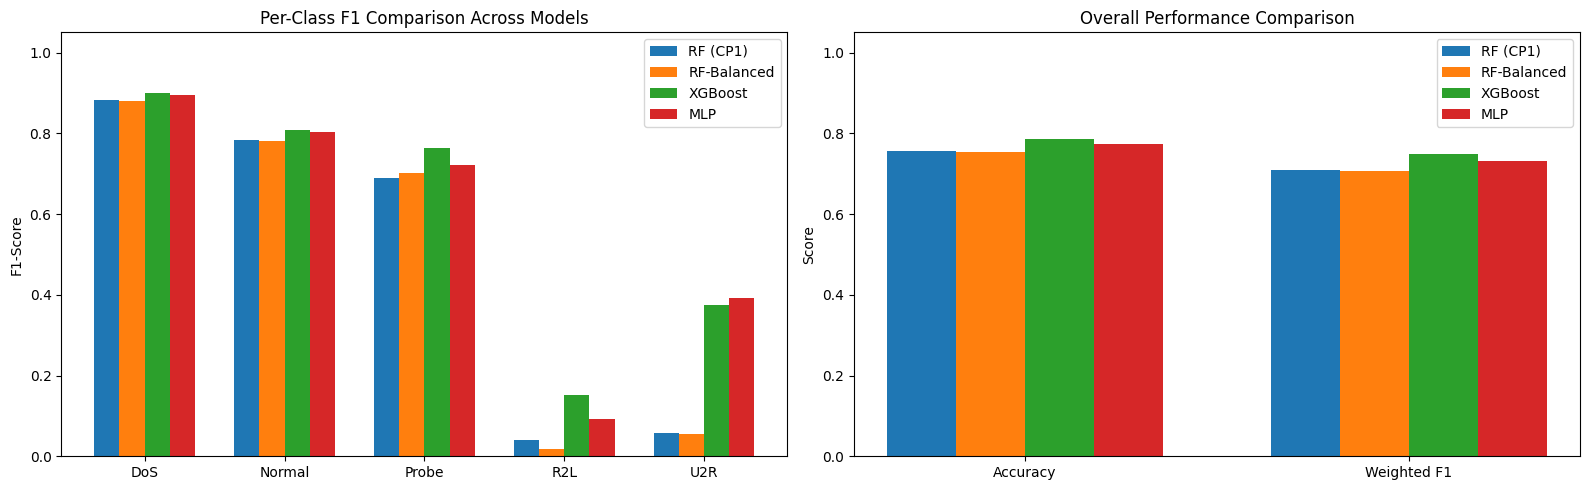

In [ ]:
models = ['RF (CP1)', 'RF-Balanced', 'XGBoost', 'MLP']
y_preds = [y_pred, y_pred_rf_bal, y_pred_xgb, y_pred_mlp]

results_rows = []
for name, yp in zip(models, y_preds):
    report = classification_report(y_test, yp,
                                   target_names=le_target.classes_, output_dict=True)
    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, yp),
        'Weighted F1': f1_score(y_test, yp, average='weighted'),}

    for cls in le_target.classes_:
        row[f'{cls} F1'] = report[cls]['f1-score']
        row[f'{cls} Recall'] = report[cls]['recall']
    results_rows.append(row)

results_df = pd.DataFrame(results_rows)
display(results_df.round(4))

# Bar chart: per-class F1 comparison
f1_cols = [c for c in results_df.columns if c.endswith(' F1') and c != 'Weighted F1']
class_names = [c.replace(' F1', '') for c in f1_cols]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(class_names))
width = 0.18
for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [row[c] for c in f1_cols]
    axes[0].bar(x + i * width, vals, width, label=row['Model'])

axes[0].set_ylabel('F1-Score')
axes[0].set_title('Per-Class F1 Comparison Across Models')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(class_names)
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# Bar chart: overall metrics
metrics = ['Accuracy', 'Weighted F1']
x2 = np.arange(len(metrics))
for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    axes[1].bar(x2 + i * width, vals, width, label=row['Model'])

axes[1].set_ylabel('Score')
axes[1].set_title('Overall Performance Comparison')
axes[1].set_xticks(x2 + width * 1.5)
axes[1].set_xticklabels(metrics)
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('cp2_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. MLP with Class Balancing

In [ ]:
# Oversample minority classes to match the majority class count.
def create_balanced_dataset(X, y, random_state=42):
    unique, counts = np.unique(y, return_counts=True)
    max_count = counts.max()

    X_balanced = []
    y_balanced = []

    for cls in unique:
        mask = (y == cls)
        X_cls = X[mask]
        y_cls = y[mask]

        if len(y_cls) < max_count:
            X_up, y_up = resample(
                X_cls, y_cls,
                replace=True,
                n_samples=max_count,
                random_state=random_state
            )
            X_balanced.append(X_up)
            y_balanced.append(y_up)
        else:
            X_balanced.append(X_cls)
            y_balanced.append(y_cls)

    return np.vstack(X_balanced), np.concatenate(y_balanced)

X_train_bal, y_train_bal = create_balanced_dataset(X_train_scaled, y_train)
print(f"Original training size: {len(y_train)}")
print(f"Balanced training size: {len(y_train_bal)}")
print(f"Class distribution after balancing: {dict(zip(*np.unique(y_train_bal, return_counts=True)))}")

mlp_weighted = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=100,
    batch_size=256,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42)

mlp_weighted.fit(X_train_bal, y_train_bal)

y_pred_mlp_w = mlp_weighted.predict(X_test_scaled)

acc_mlp_w = accuracy_score(y_test, y_pred_mlp_w)
f1_mlp_w = f1_score(y_test, y_pred_mlp_w, average='weighted')
print(f"\nMLP (Balanced) Test Accuracy:      {acc_mlp_w:.4f}")
print(f"MLP (Balanced) Test F1 (weighted): {f1_mlp_w:.4f}")
print("\nMLP (Balanced) Classification Report:")
print(classification_report(y_test, y_pred_mlp_w, target_names=le_target.classes_))


Original training size: 125973
Balanced training size: 336715
Class distribution after balancing: {np.int64(0): np.int64(67343), np.int64(1): np.int64(67343), np.int64(2): np.int64(67343), np.int64(3): np.int64(67343), np.int64(4): np.int64(67343)}

MLP (Balanced) Test Accuracy:      0.7648
MLP (Balanced) Test F1 (weighted): 0.7335

MLP (Balanced) Classification Report:
              precision    recall  f1-score   support

         DoS       0.97      0.80      0.88      7458
      Normal       0.68      0.97      0.80      9711
       Probe       0.80      0.63      0.70      2421
         R2L       0.67      0.11      0.19      2887
         U2R       0.26      0.28      0.27        67

    accuracy                           0.76     22544
   macro avg       0.68      0.56      0.57     22544
weighted avg       0.78      0.76      0.73     22544



## 12. SMOTE (Synthetic Minority Oversampling)

In [ ]:
# SMOTE generates synthetic minority samples by interpolating between
# existing minority neighbors, rather than duplicating existing samples

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training size: {len(y_train)}")
print(f"SMOTE training size:    {len(y_train_smote)}")

# XGBoost on SMOTE data (no sample weights needed - classes already balanced)
xgb_smote = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1)

xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test_scaled)

acc_xgb_smote = accuracy_score(y_test, y_pred_xgb_smote)
f1_xgb_smote = f1_score(y_test, y_pred_xgb_smote, average='weighted')
print(f"\nXGBoost+SMOTE Test Accuracy:      {acc_xgb_smote:.4f}")
print(f"XGBoost+SMOTE Test F1 (weighted): {f1_xgb_smote:.4f}")
print("\nXGBoost+SMOTE Classification Report:")
print(classification_report(y_test, y_pred_xgb_smote, target_names=le_target.classes_))

# MLP on SMOTE data
mlp_smote = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=100,
    batch_size=256,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42)

mlp_smote.fit(X_train_smote, y_train_smote)

y_pred_mlp_smote = mlp_smote.predict(X_test_scaled)

acc_mlp_smote = accuracy_score(y_test, y_pred_mlp_smote)
f1_mlp_smote = f1_score(y_test, y_pred_mlp_smote, average='weighted')
print(f"\nMLP+SMOTE Test Accuracy:      {acc_mlp_smote:.4f}")
print(f"MLP+SMOTE Test F1 (weighted): {f1_mlp_smote:.4f}")
print("\nMLP+SMOTE Classification Report:")
print(classification_report(y_test, y_pred_mlp_smote, target_names=le_target.classes_))


Original training size: 125973
SMOTE training size:    336715

XGBoost+SMOTE Test Accuracy:      0.7858
XGBoost+SMOTE Test F1 (weighted): 0.7541

XGBoost+SMOTE Classification Report:
              precision    recall  f1-score   support

         DoS       0.96      0.83      0.89      7458
      Normal       0.69      0.97      0.81      9711
       Probe       0.84      0.70      0.76      2421
         R2L       0.98      0.12      0.22      2887
         U2R       0.70      0.31      0.43        67

    accuracy                           0.79     22544
   macro avg       0.83      0.59      0.62     22544
weighted avg       0.83      0.79      0.75     22544


MLP+SMOTE Test Accuracy:      0.7709
MLP+SMOTE Test F1 (weighted): 0.7371

MLP+SMOTE Classification Report:
              precision    recall  f1-score   support

         DoS       0.96      0.83      0.89      7458
      Normal       0.68      0.97      0.80      9711
       Probe       0.81      0.60      0.69      2421
  

## 13. Feature Selection using XGBoost Importance


In [ ]:
# Get feature importances from the best XGBoost model (with class weighting)
feat_names = preprocessor.get_feature_names_out()
importances = xgb.feature_importances_
feat_importance_df = pd.DataFrame({'feature': feat_names,
    'importance': importances}).sort_values('importance', ascending=False)

# Select top-K features
TOP_K = 30
top_features = feat_importance_df.head(TOP_K)['feature'].tolist()
top_feature_indices = [list(feat_names).index(f) for f in top_features]

print(f"Top {TOP_K} features selected:")
for i, row in feat_importance_df.head(TOP_K).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# Create reduced feature sets
X_train_reduced = X_train_scaled[:, top_feature_indices]
X_test_reduced = X_test_scaled[:, top_feature_indices]

# Train XGBoost on reduced features (with class weighting)
xgb_reduced = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1)

xgb_reduced.fit(X_train_reduced, y_train, sample_weight=sample_weights_train)

y_pred_xgb_reduced = xgb_reduced.predict(X_test_reduced)

acc_xgb_red = accuracy_score(y_test, y_pred_xgb_reduced)
f1_xgb_red = f1_score(y_test, y_pred_xgb_reduced, average='weighted')
print(f"\nXGBoost (Top {TOP_K} features) Test Accuracy:      {acc_xgb_red:.4f}")
print(f"XGBoost (Top {TOP_K} features) Test F1 (weighted): {f1_xgb_red:.4f}")
print(f"\nXGBoost (Top {TOP_K} features) Classification Report:")
print(classification_report(y_test, y_pred_xgb_reduced, target_names=le_target.classes_))


Top 30 features selected:
  cat__flag_S0: 0.1362
  cat__service_telnet: 0.1142
  cat__service_eco_i: 0.0961
  num__dst_host_serror_rate: 0.0561
  cat__service_smtp: 0.0499
  cat__service_domain_u: 0.0414
  cat__service_http: 0.0400
  num__num_failed_logins: 0.0320
  num__is_guest_login: 0.0293
  num__count: 0.0290
  num__dst_bytes: 0.0260
  cat__protocol_type_icmp: 0.0251
  num__dst_host_srv_count: 0.0229
  cat__service_ftp_data: 0.0206
  num__src_bytes: 0.0180
  cat__service_ecr_i: 0.0153
  num__root_shell: 0.0142
  num__dst_host_diff_srv_rate: 0.0136
  num__wrong_fragment: 0.0134
  cat__service_other: 0.0126
  num__num_file_creations: 0.0118
  cat__protocol_type_udp: 0.0096
  num__diff_srv_rate: 0.0094
  num__srv_count: 0.0087
  num__srv_rerror_rate: 0.0079
  cat__flag_SF: 0.0075
  num__same_srv_rate: 0.0069
  num__hot: 0.0069
  cat__flag_RSTO: 0.0068
  cat__service_ftp: 0.0066

XGBoost (Top 30 features) Test Accuracy:      0.7662
XGBoost (Top 30 features) Test F1 (weighted): 0.7228


## 14. Final Comparison (All Models)

,Model,Accuracy,Weighted F1,DoS F1,DoS Recall,Normal F1,Normal Recall,Probe F1,Probe Recall,R2L F1,R2L Recall,U2R F1,U2R Recall
0,RF (Baseline),0.7553,0.7089,0.8823,0.8139,0.7837,0.9737,0.6900,0.5952,0.0400,0.0204,0.0571,0.0299
1,RF-Balanced,0.7533,0.7054,0.8811,0.8119,0.7800,0.9738,0.7022,0.5956,0.0185,0.0094,0.0563,0.0299
2,XGBoost,0.7858,0.7484,0.8991,0.8410,0.8091,0.9724,0.7635,0.7216,0.1508,0.0817,0.3736,0.2537
3,MLP,0.7742,0.7323,0.8941,0.8321,0.8029,0.9712,0.7222,0.6844,0.0935,0.0492,0.3908,0.2537
4,MLP (Balanced),0.7648,0.7335,0.8758,0.7983,0.7967,0.9705,0.7042,0.6303,0.1889,0.1098,0.2714,0.2836
5,XGBoost+SMOTE,0.7858,0.7541,0.8942,0.8339,0.8066,0.9716,0.7599,0.6968,0.2180,0.1226,0.4330,0.3134
6,MLP+SMOTE,0.7709,0.7371,0.8892,0.8260,0.7974,0.9714,0.6907,0.6018,0.1884,0.1046,0.3758,0.4179
7,XGBoost (Top 30),0.7662,0.7228,0.8863,0.8214,0.7926,0.9712,0.7295,0.6601,0.0695,0.0360,0.3333,0.2239


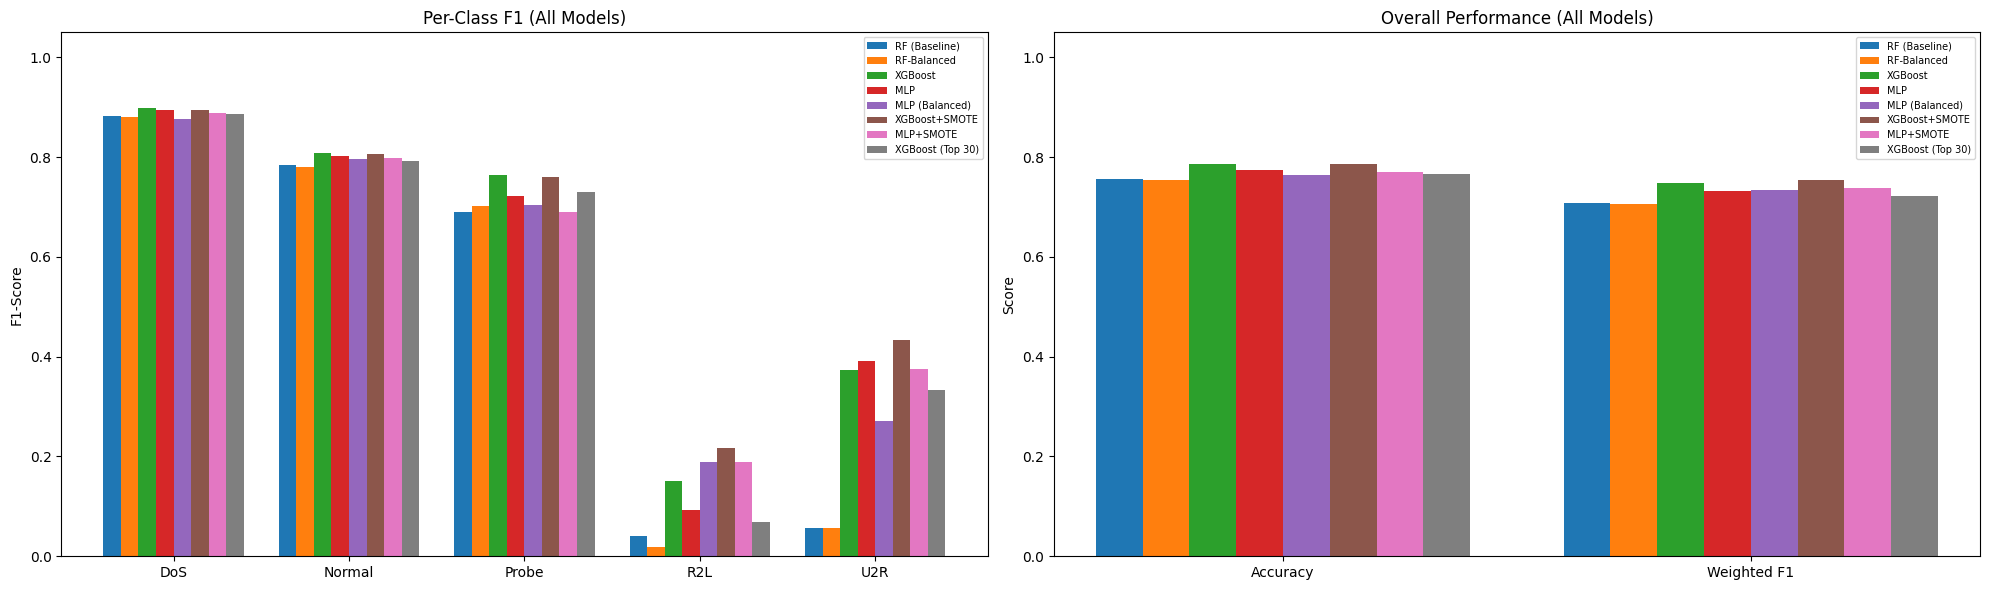

In [ ]:
all_models = [
    'RF (Baseline)', 'RF-Balanced', 'XGBoost', 'MLP',
    'MLP (Balanced)', 'XGBoost+SMOTE', 'MLP+SMOTE',
    f'XGBoost (Top {TOP_K})']

all_preds = [
    y_pred, y_pred_rf_bal, y_pred_xgb, y_pred_mlp,
    y_pred_mlp_w, y_pred_xgb_smote, y_pred_mlp_smote,
    y_pred_xgb_reduced]

final_rows = []
for name, yp in zip(all_models, all_preds):
    report = classification_report(y_test, yp,
                                   target_names=le_target.classes_,
                                   output_dict=True)
    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, yp),
        'Weighted F1': f1_score(y_test, yp, average='weighted'),}

    for cls in le_target.classes_:
        row[f'{cls} F1'] = report[cls]['f1-score']
        row[f'{cls} Recall'] = report[cls]['recall']
    final_rows.append(row)

final_df = pd.DataFrame(final_rows)
display(final_df.round(4))

# Final bar chart: per-class F1 across all models
f1_cols = [c for c in final_df.columns if c.endswith(' F1') and c != 'Weighted F1']
class_names = [c.replace(' F1', '') for c in f1_cols]

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

x = np.arange(len(class_names))
n_models = len(all_models)
width = 0.8 / n_models

for i, (_, row) in enumerate(final_df.iterrows()):
    vals = [row[c] for c in f1_cols]
    axes[0].bar(x + i * width, vals, width, label=row['Model'])

axes[0].set_ylabel('F1-Score')
axes[0].set_title('Per-Class F1 (All Models)')
axes[0].set_xticks(x + width * (n_models - 1) / 2)
axes[0].set_xticklabels(class_names)
axes[0].legend(fontsize=7, loc='upper right')
axes[0].set_ylim(0, 1.05)

# Overall metrics
metrics = ['Accuracy', 'Weighted F1']
x2 = np.arange(len(metrics))
for i, (_, row) in enumerate(final_df.iterrows()):
    vals = [row[m] for m in metrics]
    axes[1].bar(x2 + i * width, vals, width, label=row['Model'])

axes[1].set_ylabel('Score')
axes[1].set_title('Overall Performance (All Models)')
axes[1].set_xticks(x2 + width * (n_models - 1) / 2)
axes[1].set_xticklabels(metrics)
axes[1].legend(fontsize=7, loc='upper right')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

##15: XGBoost+SMOTE Model Confusion Matrix

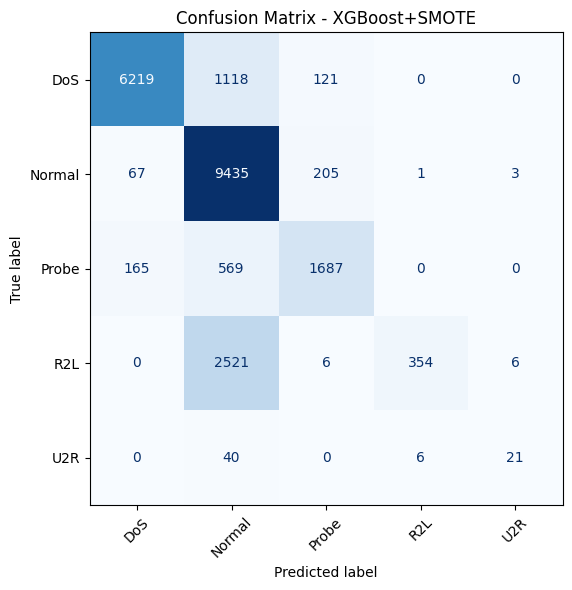

In [ ]:

# Based on the final comparison table, XGBoost+SMOTE has the best
# weighted F1 (0.7541) and is tied for the best accuracy (0.7858).
# We'll use it as our "best model" for the confusion matrix.

best_model_name = 'XGBoost+SMOTE'
best_y_pred = y_pred_xgb_smote

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, best_y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix - {best_model_name}')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('best_model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

##16: Prototype - IDS Prediction Interface

In [ ]:
# Simple inference wrapper: takes a raw flow (dict of feature values),
# applies the same preprocessing pipeline, and returns predicted class + probabilities

def classify_flow(flow_dict, model=xgb_smote, preprocessor=preprocessor,
                  label_encoder=le_target):
    """
    Classify a single network flow into one of 5 categories:
    Normal, DoS, Probe, R2L, or U2R.

    Parameters
    ----------
    flow_dict : dict
        A dictionary with feature names as keys and feature values as values.
        Must contain all features expected by the preprocessor
        (i.e. all columns in X_train before preprocessing).
    model : trained classifier
        The model to use for prediction (default: XGBoost+SMOTE model).
    preprocessor : ColumnTransformer
        The fitted preprocessor used during training.
    label_encoder : LabelEncoder
        The fitted label encoder for the target variable.

    Returns
    -------
    dict with keys:
        - 'predicted_class': str - the predicted attack category
        - 'confidence': float - max predicted probability
        - 'probabilities': dict - probability for each class
    """

    # Convert dict to DataFrame
    flow_df = pd.DataFrame([flow_dict])

    # Apply the same preprocessing as training
    flow_scaled = preprocessor.transform(flow_df)

    # Predict class
    pred_encoded = model.predict(flow_scaled)[0]
    pred_label = label_encoder.inverse_transform([pred_encoded])[0]

    # Predict probabilities
    pred_proba = model.predict_proba(flow_scaled)[0]
    proba_dict = {
        label_encoder.inverse_transform([i])[0]: float(prob)
        for i, prob in enumerate(pred_proba)}

    confidence = float(pred_proba.max())

    return {
        'predicted_class': pred_label,
        'confidence': confidence,
        'probabilities': proba_dict}

# Demo: classify the first test sample
sample_flow = X_test.iloc[0].to_dict()
result = classify_flow(sample_flow)

print("Prototype IDS Classification Demo\n")
print(f"Predicted class: {result['predicted_class']}")
print(f"Confidence:      {result['confidence']:.4f}")
print(f"Probabilities:")
for cls, prob in result['probabilities'].items():
    print(f"  {cls}: {prob:.4f}")

true_label = le_target.inverse_transform([y_test[0]])[0]
print(f"\nTrue label:      {true_label}")



Prototype IDS Classification Demo

Predicted class: DoS
Confidence:      1.0000
Probabilities:
  DoS: 1.0000
  Normal: 0.0000
  Probe: 0.0000
  R2L: 0.0000
  U2R: 0.0000

True label:      DoS
